In [1]:
# Cell 1 — imports (same as NB1)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Cell 2 — load and audit
df = pd.read_csv(r"C:\Users\waghs.DESKTOP-OFO3QK6\churn-prediction-analysis\data\raw\WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(df.shape)
print(df['Attrition'].value_counts())
print(f"Attrition rate: {df['Attrition'].eq('Yes').mean()*100:.1f}%")

(1470, 35)
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition rate: 16.1%


In [11]:
# Cell 3 — drop useless columns (constant values)
df = df.drop(['EmployeeCount','EmployeeNumber',
              'Over18','StandardHours'], axis=1)


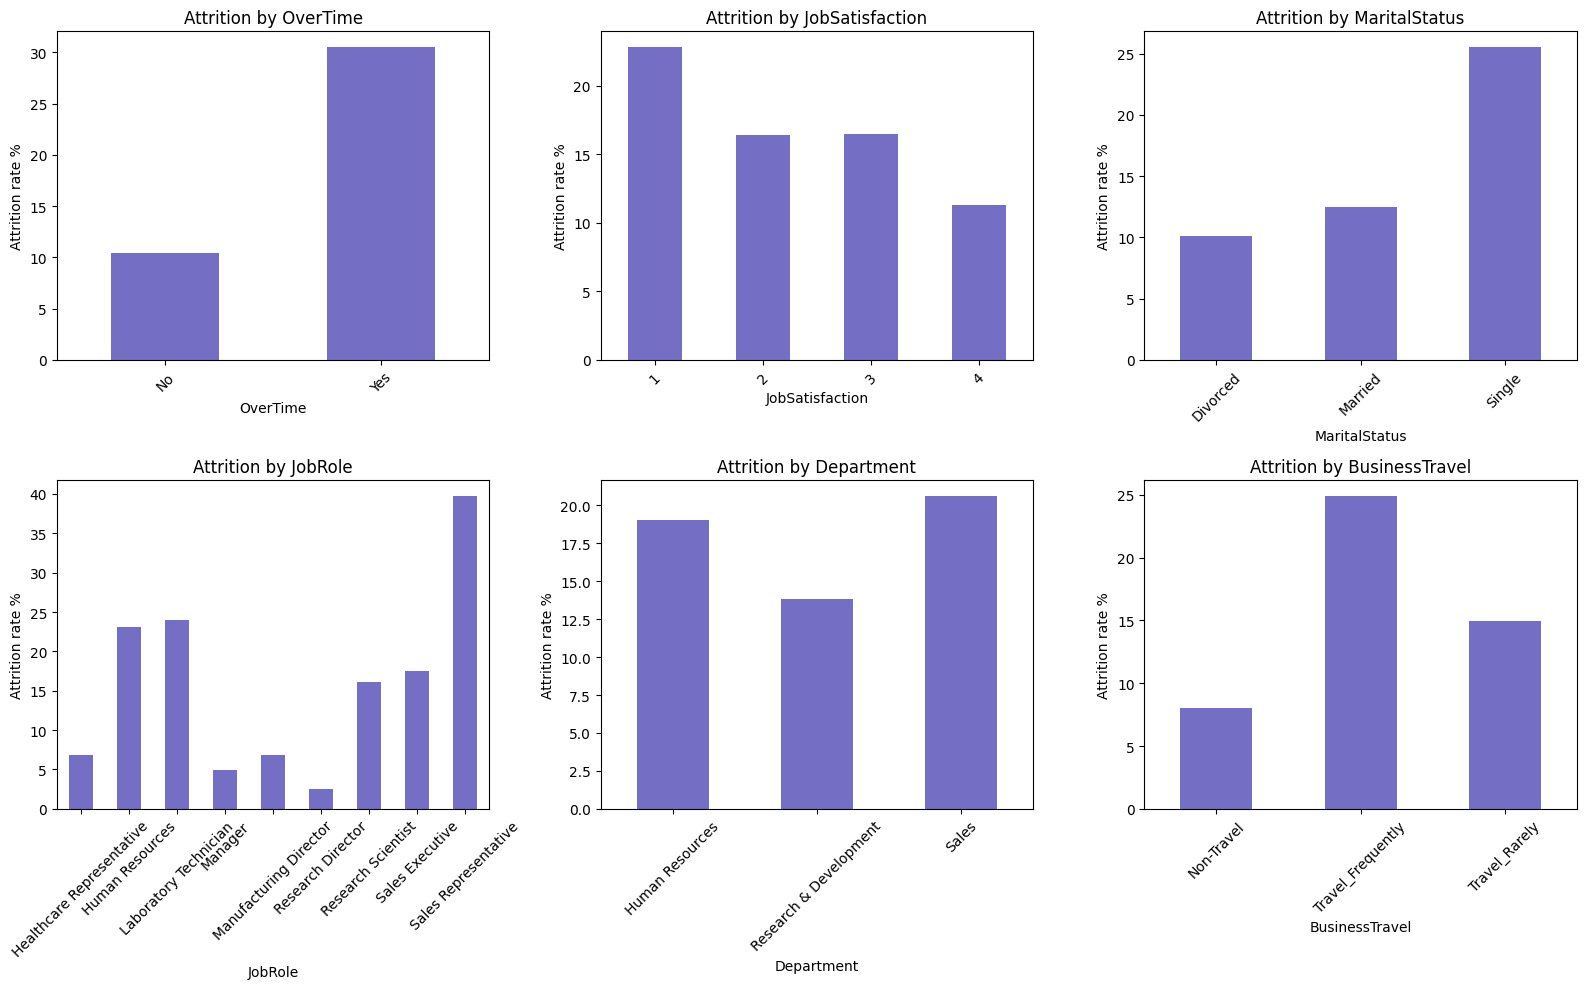

In [13]:
# Cell 4 — attrition by key HR factors
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
factors = ['OverTime','JobSatisfaction','MaritalStatus',
           'JobRole','Department','BusinessTravel']
for ax, col in zip(axes.flat, factors):
    rates = df.groupby(col)['Attrition'].apply(
        lambda x: (x=='Yes').mean()*100)
    rates.plot(kind='bar', ax=ax, color='#534AB7', alpha=0.8)
    ax.set_title(f'Attrition by {col}')
    ax.set_ylabel('Attrition rate %')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

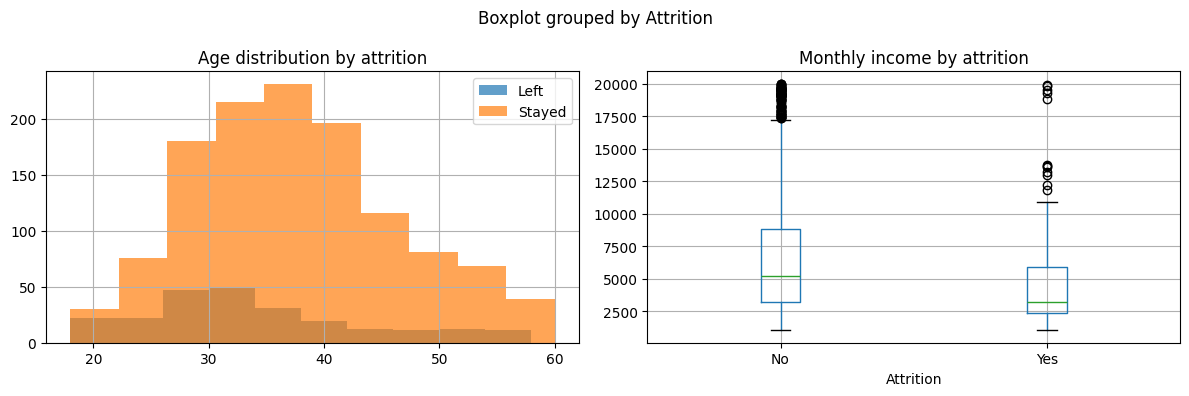

In [14]:
# Cell 5 — age and income distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[df['Attrition']=='Yes']['Age'].hist(ax=axes[0], alpha=0.7, label='Left')
df[df['Attrition']=='No']['Age'].hist(ax=axes[0], alpha=0.7, label='Stayed')
axes[0].legend(); axes[0].set_title('Age distribution by attrition')
df.boxplot(column='MonthlyIncome', by='Attrition', ax=axes[1])
axes[1].set_title('Monthly income by attrition')
plt.tight_layout(); plt.show()

In [15]:
# Cell 6 — encode and save
df['Attrition_binary'] = (df['Attrition'] == 'Yes').astype(int)
df_encoded = pd.get_dummies(df.drop('Attrition', axis=1))
df_encoded['Attrition'] = df['Attrition_binary'].values
df_encoded.to_csv('../data/processed/employee_attrition_clean.csv', index=False)
print('Saved. Shape:', df_encoded.shape)

Saved. Shape: (1470, 53)
